In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Resolve the project root whether the notebook is run from the repo root or from /utils.
current_dir = Path.cwd().resolve()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise RuntimeError("Project root was not found.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.TemporaryClean_thresholds import (
    add_temporal_groups,
    calculate_similarity,
    evaluate_threshold_grid,
    sample_pairs_for_threshold_review,
    export_pair_review_images,
    evaluate_thresholds_against_manual_labels,
    recommend_conservative_threshold,
)

# Centralized paths used by the threshold tuning workflow.
METADATA_PATH = PROJECT_ROOT / "data" / "phase3" / "phase3_metrics_train.csv"
IMAGES_DIR = PROJECT_ROOT / "data" / "phase2" / "framesv2"

REPORTS_DIR = PROJECT_ROOT / "reports" / "deduplication_threshold_tuning"
PAIR_REVIEW_DIR = REPORTS_DIR / "pair_review_images"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PAIR_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# Candidate pairs are only compared within short temporal windows from the same video.
TEMPORAL_TOLERANCE_SECONDS = 6.0

# Grid searched later to understand how strict or permissive each threshold pair is.
SSIM_CANDIDATES = [0.70, 0.75, 0.80, 0.85, 0.90]
PHASH_CANDIDATES = [4, 6, 8, 10, 12]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_PATH:", METADATA_PATH)
print("IMAGES_DIR:", IMAGES_DIR)

PROJECT_ROOT: C:\Users\luis\Documents\TFG - Data-Centric AI
METADATA_PATH: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase3\phase3_metrics_train.csv
IMAGES_DIR: C:\Users\luis\Documents\TFG - Data-Centric AI\data\phase2\framesv2


In [2]:
df = pd.read_csv(METADATA_PATH)

print("Training images:", len(df))
display(df.head())

# Assign a temporal group id so only nearby frames are compared with each other.
grouped_df = add_temporal_groups(
    dataframe=df,
    temporal_tolerance_seconds=TEMPORAL_TOLERANCE_SECONDS,
)

# Summarize each group before deriving the total number of pairwise comparisons.
temporal_summary = (
    grouped_df
    .groupby("group_id")
    .agg(
        num_images=("filename", "count"),
        histology=("histology", "first"),
        min_time=("elapsed_seconds", "min"),
        max_time=("elapsed_seconds", "max"),
    )
    .reset_index()
)

temporal_summary["duration"] = (
    temporal_summary["max_time"] - temporal_summary["min_time"]
)

# Number of unordered image pairs inside every temporal group: n * (n - 1) / 2.
total_pairs = int(
    temporal_summary["num_images"]
    .apply(lambda n: n * (n - 1) / 2)
    .sum()
)

print("Temporal groups:", grouped_df["group_id"].nunique())
print("Comparable pairs:", total_pairs)

Training images: 7868


,filename,histology,patient_id,day,R,F,video_filename,elapsed_seconds,source_type,detection_confidence,bbox_area_ratio,brightness_v_mean,uniformity_entropy,laplacian_variance
0,20241213_102820_R0_F0_S1_34b16ba5d8336515.jpg,Adenoma,4101414,20241213,R0,F0,20241213_102820_R2_34b16ba5d8336515.mp4,0.0,original,0.0,0.0,84.247481,7.057979,300.173878
1,20241213_102821_R2_F0_S1_34b16ba5d8336515.jpg,Adenoma,4101414,20241213,R2,F0,20241213_102820_R2_34b16ba5d8336515.mp4,1.0,original,0.0,0.0,76.631638,6.373658,137.840116
2,20241213_103001_R2_F0_S8_34b16ba5d8336515.jpg,Adenoma,4101414,20241213,R2,F0,20241213_102820_R2_34b16ba5d8336515.mp4,101.0,original,0.0,0.0,131.618293,6.833271,226.689459
3,20241213_103008_R2_F0_S9_34b16ba5d8336515.jpg,Adenoma,4101414,20241213,R2,F0,20241213_102820_R2_34b16ba5d8336515.mp4,108.0,original,0.0,0.0,98.607903,7.445012,229.116787
4,20241213_103032_R2_F0_S10_34b16ba5d8336515.jpg,Adenoma,4101414,20241213,R2,F0,20241213_102820_R2_34b16ba5d8336515.mp4,132.0,original,0.0,0.0,82.606557,7.261632,200.369909


Temporal groups: 1703
Comparable pairs: 28801


In [3]:
SIMILARITY_PAIRS_PATH = REPORTS_DIR / "similarity_pairs.csv"

# Similarity calculation is cached because SSIM and pHash extraction are the slow step.
if SIMILARITY_PAIRS_PATH.exists():
    similarity_pairs_df = pd.read_csv(SIMILARITY_PAIRS_PATH)
    print("Pairs loaded from:", SIMILARITY_PAIRS_PATH)
else:
    similarity_pairs_df = calculate_similarity(
        dataframe=grouped_df,
        images_dir=IMAGES_DIR,
        ssim_threshold=0.75,
        phash_distance_threshold=8,
    )

    similarity_pairs_df.to_csv(SIMILARITY_PAIRS_PATH, index=False)
    print("Pairs calculated and saved to:", SIMILARITY_PAIRS_PATH)

print("Calculated comparable pairs:", len(similarity_pairs_df))

display(similarity_pairs_df.head())
display(similarity_pairs_df[["ssim", "phash_distance"]].describe())

Pairs calculated and saved to: C:\Users\luis\Documents\TFG - Data-Centric AI\reports\deduplication_threshold_tuning\similarity_pairs.csv
Calculated comparable pairs: 28801


,group_id,filename_a,filename_b,ssim,phash_distance,ssim_threshold,phash_distance_threshold,redundant_by_ssim,redundant_by_phash,is_redundant,redundancy_method,similarity_zone
0,289827_20241204_R1_F0_20241204_134033_R1_8f99b...,20241204_134039_R1_F0_S1_8f99b423ac93fa5b.jpg,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_1.jpg,0.780899,0,0.75,8,True,True,True,both,borderline
1,289827_20241204_R1_F0_20241204_134033_R1_8f99b...,20241204_134039_R1_F0_S1_8f99b423ac93fa5b.jpg,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_2.jpg,0.346598,2,0.75,8,False,True,False,phash,single_metric_match
2,289827_20241204_R1_F0_20241204_134033_R1_8f99b...,20241204_134039_R1_F0_S1_8f99b423ac93fa5b.jpg,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_3.jpg,0.340020,0,0.75,8,False,True,False,phash,single_metric_match
3,289827_20241204_R1_F0_20241204_134033_R1_8f99b...,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_1.jpg,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_2.jpg,0.351457,2,0.75,8,False,True,False,phash,single_metric_match
4,289827_20241204_R1_F0_20241204_134033_R1_8f99b...,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_1.jpg,20241204_134039_R1_F0_S1_8f99b423ac93fa5b_3.jpg,0.343688,0,0.75,8,False,True,False,phash,single_metric_match


,ssim,phash_distance
count,28801.000000,28801.000000
mean,0.517305,16.008125
std,0.167431,8.966423
min,0.059894,0.000000
25%,0.399003,8.000000
50%,0.501027,16.000000
75%,0.610097,22.000000
max,1.000000,44.000000


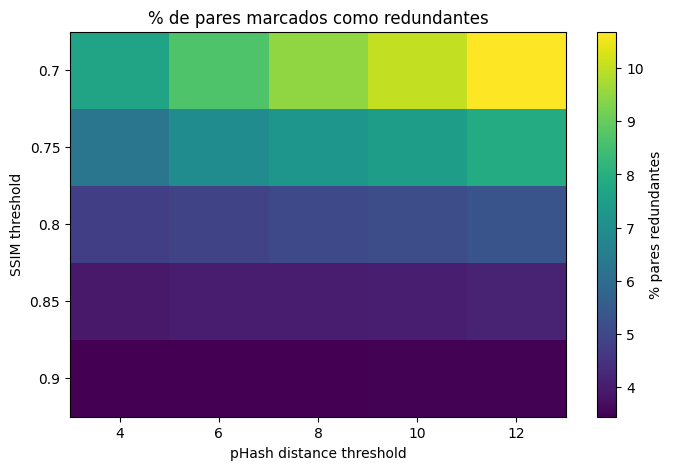

In [7]:
# Evaluate each SSIM/pHash combination over the same precomputed pair table.
threshold_grid_df = evaluate_threshold_grid(
    similarity_pairs_df=similarity_pairs_df,
    ssim_thresholds=SSIM_CANDIDATES,
    phash_distance_thresholds=PHASH_CANDIDATES,
)

# This percentage is an aggressiveness proxy: higher values remove more pairs.
threshold_grid_df["redundant_pair_percentage"] = (
    100 * threshold_grid_df["redundant_pairs"] / threshold_grid_df["total_pairs"]
)

threshold_grid_df = threshold_grid_df.sort_values(
    ["ssim_threshold", "phash_distance_threshold"],
    ascending=[False, True],
).reset_index(drop=True)

threshold_grid_df.to_csv(
    REPORTS_DIR / "threshold_grid_aggressiveness.csv",
    index=False,
)

# Heatmap matrix: rows are SSIM thresholds and columns are pHash distance thresholds.
pivot = threshold_grid_df.pivot(
    index="ssim_threshold",
    columns="phash_distance_threshold",
    values="redundant_pair_percentage",
)

plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("pHash distance threshold")
plt.ylabel("SSIM threshold")
plt.title("% of pairs marked as redundant")
plt.colorbar(label="% redundant pairs")
plt.show()

In [ ]:
# Sample candidate pairs from different threshold zones for manual visual review.
review_pairs_df = sample_pairs_for_threshold_review(
    similarity_pairs_df=similarity_pairs_df,
    n_per_zone=25,
    random_state=42,
)

# Export side-by-side images so labels can be assigned outside the notebook.
review_pairs_df = export_pair_review_images(
    review_pairs_df=review_pairs_df,
    images_dir=IMAGES_DIR,
    output_dir=PAIR_REVIEW_DIR,
    image_size=(320, 180),
)

REVIEW_CSV_PATH = REPORTS_DIR / "manual_pair_review.csv"
review_pairs_df.to_csv(REVIEW_CSV_PATH, index=False)

print("CSV to label:", REVIEW_CSV_PATH)
print("Images exported to:", PAIR_REVIEW_DIR)

CSV para etiquetar: C:\Users\luis\Documents\TFG - Data-Centric AI\reports\deduplication_threshold_tuning\manual_pair_review.csv
Images exported to: C:\Users\luis\Documents\TFG - Data-Centric AI\reports\deduplication_threshold_tuning\pair_review_images


,similarity_zone,filename_a,filename_b,ssim,phash_distance,manual_label,manual_comment,review_image_path
0,borderline,20250410_093956_R3_F0_S2_3008a818b79cf7c1_1.jpg,20250410_093956_R3_F0_S2_3008a818b79cf7c1_2.jpg,0.879965,8,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
1,borderline,20241209_104227_R5_F0_S3_0df333d196a4d1ea.jpg,20241209_104227_R5_F0_S3_0df333d196a4d1ea_1.jpg,0.847809,4,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
2,borderline,20250127_100014_R9_F0_S2_448cf72de1c9771e_1.jpg,20250127_100014_R9_F0_S2_448cf72de1c9771e_2.jpg,0.837221,0,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
3,borderline,20241209_135434_R3_F0_S3_45490f30d33a177c_3.jpg,20241209_135434_R3_F0_S3_45490f30d33a177c_4.jpg,0.829097,4,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
4,borderline,20250306_100136_R7_F0_S1_55bbbf6391713ff2.jpg,20250306_100136_R7_F0_S1_55bbbf6391713ff2_2.jpg,0.828755,2,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
5,borderline,20250506_103218_R3_F0_S7_dd76e3b415a7e977_10.jpg,20250506_103218_R3_F0_S7_dd76e3b415a7e977_13.jpg,0.815580,0,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
6,borderline,20241209_135436_R3_F0_S4_45490f30d33a177c_2.jpg,20241209_135436_R3_F0_S4_45490f30d33a177c_3.jpg,0.810483,10,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
7,borderline,20250414_135814_R6_F0_S1_90985f258ff468af_1.jpg,20250414_135815_R6_F0_S2_90985f258ff468af_1.jpg,0.808084,0,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
8,borderline,20250227_101759_R2_F0_S4_fdc41232df98fda5_2.jpg,20250227_101759_R2_F0_S4_fdc41232df98fda5_3.jpg,0.804295,0,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...
9,borderline,20241202_134039_R1_F1_S2_1e3f2cc3a75c08f9_2.jpg,20241202_134039_R1_F1_S2_1e3f2cc3a75c08f9_3.jpg,0.794180,8,,,C:\Users\luis\Documents\TFG - Data-Centric AI\...


In [10]:
labeled_pairs_df = pd.read_csv(REVIEW_CSV_PATH, delimiter=";")

# Normalize manual labels before validating them against the accepted vocabulary.
labeled_pairs_df["manual_label"] = (
    labeled_pairs_df["manual_label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

valid_labels = {
    "",
    "duplicate",
    "redundant",
    "useful_variant",
    "different",
    "uncertain",
}

invalid_labels = set(labeled_pairs_df["manual_label"].unique()) - valid_labels

if invalid_labels:
    raise ValueError(f"Invalid labels: {invalid_labels}")

label_counts = (
    labeled_pairs_df["manual_label"]
    .value_counts()
    .rename_axis("manual_label")
    .reset_index(name="count")
)

print(label_counts)

     manual_label  count
0       duplicate     59
1       redundant     22
2       different     20
3  useful_variant     14
4       uncertain     10


In [11]:
# Treat duplicate/redundant as positives and useful/different pairs as negatives.
manual_evaluation_df = evaluate_thresholds_against_manual_labels(
    labeled_pairs_df=labeled_pairs_df,
    ssim_thresholds=SSIM_CANDIDATES,
    phash_distance_thresholds=PHASH_CANDIDATES,
    positive_labels=("duplicate", "redundant"),
    negative_labels=("useful_variant", "different"),
)

# Prefer high precision first, then recall, while minimizing false positives.
manual_evaluation_df = manual_evaluation_df.sort_values(
    ["precision", "recall", "false_positive"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(manual_evaluation_df)

manual_evaluation_df.to_csv(
    REPORTS_DIR / "manual_threshold_evaluation.csv",
    index=False,
)

,ssim_threshold,phash_distance_threshold,labelled_pairs,true_positive,false_positive,false_negative,true_negative,precision,recall
0,0.80,10,115,57,0,24,34,1.000000,0.703704
1,0.80,12,115,57,0,24,34,1.000000,0.703704
2,0.80,8,115,56,0,25,34,1.000000,0.691358
3,0.80,6,115,55,0,26,34,1.000000,0.679012
4,0.80,4,115,54,0,27,34,1.000000,0.666667
5,0.85,8,115,49,0,32,34,1.000000,0.604938
6,0.85,10,115,49,0,32,34,1.000000,0.604938
7,0.85,12,115,49,0,32,34,1.000000,0.604938
8,0.85,6,115,48,0,33,34,1.000000,0.592593
9,0.85,4,115,47,0,34,34,1.000000,0.580247


In [13]:
# Select the most conservative threshold pair that satisfies the minimum precision target.
recommended_df = recommend_conservative_threshold(
    evaluation_df=manual_evaluation_df,
    min_precision=0.90,
)

print(recommended_df)

selected = recommended_df.iloc[0]

FINAL_SSIM_THRESHOLD = float(selected["ssim_threshold"])
FINAL_PHASH_DISTANCE_THRESHOLD = int(selected["phash_distance_threshold"])

print("Selected final thresholds:")
print(f"SSIM >= {FINAL_SSIM_THRESHOLD:.2f}")
print(f"pHash distance <= {FINAL_PHASH_DISTANCE_THRESHOLD}")

final_text = f"""
Selected configuration for the deduplication phase:

- Temporal window: {TEMPORAL_TOLERANCE_SECONDS:.1f} seconds
- SSIM threshold: {FINAL_SSIM_THRESHOLD:.2f}
- pHash distance threshold: {FINAL_PHASH_DISTANCE_THRESHOLD}

The redundancy decision requires both conditions to be met at the same time.
Thresholds were selected through visual review of candidate pairs, prioritizing a conservative strategy: maximize precision for pairs marked as redundant to avoid removing images that add useful training variability.
"""

print(final_text)

(CONFIG_PATH := REPORTS_DIR / "selected_deduplication_thresholds.txt").write_text(
    final_text,
    encoding="utf-8",
)

print("Saved to:", CONFIG_PATH)

    ssim_threshold  phash_distance_threshold  labelled_pairs  true_positive  \
0             0.80                        10             115             57   
1             0.80                        12             115             57   
2             0.80                         8             115             56   
3             0.80                         6             115             55   
4             0.80                         4             115             54   
5             0.85                         8             115             49   
6             0.85                        10             115             49   
7             0.85                        12             115             49   
8             0.85                         6             115             48   
9             0.85                         4             115             47   
10            0.90                         4             115             25   
11            0.90                         6        